In [1]:
import pandas as pd     # 数据表
import numpy as np     # 数组
import re     # 正则表达式
import jieba     # 中文分词
import matplotlib.pyplot as plt     # 画图
from gensim.models import Word2Vec     # 训练词嵌入模型
# import gensim.downloader as api     # 导入云端的已训练好的词向量
from gensim.models import KeyedVectors     # 加载自己本地个性化的已训练好的词向量
from sklearn.metrics.pairwise import cosine_similarity     # 计算向量之间的余弦相似度
from sklearn.decomposition import PCA     # 语义空间降维，用于展示词语在二维空间的相对位置

In [2]:
df = pd.read_excel('四年级.xlsx').astype(str)
df[:20]

,序号,年级,作文题目,作文id,作文标题,开头score,结尾score,审题score,立意score,详略score,条理score,选材score,想象score,思想score
0,1,4,游_____,660,游蒲津公园,8.0,7.8,9.565,9.0,9.2,9.5,nan,nan,nan
1,2,4,我学会了_____,662,我学会了包饺子,8.25,8.7,9.6,7.9,9.0,nan,nan,nan,nan
2,3,4,我的奇思妙想,656,我的发明,8.25,7.8,7.485,7.8,8.0,nan,nan,9.0,nan
3,4,4,我的奇思妙想,656,多功能房子,8.75,5.2,5.84,8.2,7.1,nan,nan,8.75,nan
4,5,4,我的动物朋友,658,我的圈圈朋友,7.75,8.5,8.48,9.75,9.2,nan,nan,nan,nan
5,6,4,游_____,660,游西湖,9.25,8.3,9.84,9.75,9.5,9.5,nan,nan,nan
6,7,4,我的自画像,664,我的“自画像”,8.75,9.175,7.635,9.11,9.24,nan,8.55,nan,nan
7,8,4,我的动物朋友,658,流星,8.5,8.5,8.585,9.0,9.5,nan,nan,nan,nan
8,9,4,我的动物朋友,678,我家的小“奶牛”——露月,8.75,8.1,9.6,10.0,9.5,nan,nan,nan,nan
9,10,4,我学会了_____,682,我学会了游泳,9.0,8.3,8.5,7.8,8.4,nan,nan,nan,nan


In [3]:
def remove_nums(text):
    nonums = re.sub('[^\u4e00-\u9fa5]+', '', text)
    return nonums
test = df['作文标题'][8]
remove_nums(test)

'我家的小奶牛露月'

In [4]:
# 加载中文停用词词典，可个性化设置
stopwords = open('stopwords.txt', encoding = 'utf-8').read()

def clean_text(text):
    words = jieba.lcut(text)
    words = [w for w in words if w not in stopwords]
    return ' '.join(words)
test = df['作文标题'][8]
clean_text(test)

Building prefix dict from the default dictionary ...
Loading model from cache /var/folders/kk/ylyfvmrj6zv853wrvp3s_0180000gn/T/jieba.cache
Loading model cost 0.392 seconds.
Prefix dict has been built successfully.


'我家 奶牛 露月'

In [5]:
df['作文标题分词'] = df['作文标题'].apply(remove_nums)
df['作文标题分词'] = df['作文标题分词'].apply(clean_text)
df.head()

,序号,年级,作文题目,作文id,作文标题,开头score,结尾score,审题score,立意score,详略score,条理score,选材score,想象score,思想score,作文标题分词
0,1,4,游_____,660,游蒲津公园,8.0,7.8,9.565,9.0,9.2,9.5,nan,nan,nan,游 蒲津 公园
1,2,4,我学会了_____,662,我学会了包饺子,8.25,8.7,9.6,7.9,9.0,nan,nan,nan,nan,学会 包 饺子
2,3,4,我的奇思妙想,656,我的发明,8.25,7.8,7.485,7.8,8.0,nan,nan,9.0,nan,发明
3,4,4,我的奇思妙想,656,多功能房子,8.75,5.2,5.84,8.2,7.1,nan,nan,8.75,nan,多功能 房子
4,5,4,我的动物朋友,658,我的圈圈朋友,7.75,8.5,8.48,9.75,9.2,nan,nan,nan,nan,圈圈 朋友


In [6]:
import pandas as pd #数据表
import numpy as np #数组运算
import nltk #英文语料处理
import re #正则表达式（用于数据清洗）
import matplotlib.pyplot as plt #画图
from wordcloud import WordCloud #词云图
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import TweetTokenizer
from sklearn.feature_extraction.text import CountVectorizer

In [7]:
text=list(df['作文标题分词'])[:100]
text=" ".join(text)
lemmatizer=WordNetLemmatizer()
#转换为小写
text=text.lower()
#移除URL
text=re.sub(r'http\S+','',text)
text
#初始化CounVectorizer
vectorizer=CountVectorizer()
#将文本数据转换为词袋特征矩阵
X=vectorizer.fit_transform(df['作文标题分词'])
#展示特征矩阵的形状
print('词袋特征矩阵的形状:',X.shape)
#展示词袋模型中的所有特征词
print('特征词列表:',vectorizer.get_feature_names_out()[:20])

词袋特征矩阵的形状: (44834, 6663)
特征词列表: ['一不小心' '一个' '一个男孩' '一二三' '一件' '一份' '一写' '一动' '一双' '一只' '一号' '一周' '一场'
 '一头' '一家' '一家子' '一对' '一封信' '一平方米' '一扇']


In [8]:
#获取词汇表
feature_words=vectorizer.get_feature_names_out()
#计算词频
word_freq=dict(zip(feature_words,X.sum(axis=0).A1))

In [9]:
sorted(word_freq.items(),key=lambda X: X[1],reverse=True)
items = list(word_freq.items())
items.sort(key=lambda x:x[1], reverse=True)
for i in range(100):
    word, count = items[i]
    print("{0:<100}{1:>5}".format(word,count))
print ('已统计数量排前100的词')

学会                                                                                                   6832
朋友                                                                                                   5930
动物                                                                                                   5756
自画像                                                                                                  3460
智能                                                                                                   2872
自行车                                                                                                  2610
乐园                                                                                                   2300
汽车                                                                                                   1868
快乐                                                                                                   1528
奇思妙想                                          

In [10]:
import matplotlib.pyplot as plt
from matplotlib import font_manager
 
#for font in font_manager.fontManager.ttflist:
    # 查看字体名以及对应的字体文件名
   # print(font.name, '-', font.fname)

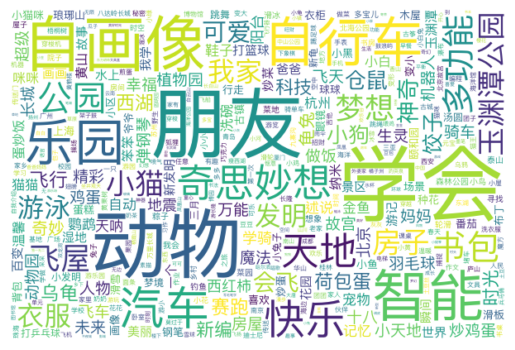

In [11]:
# 根据词袋模型分析结果绘制词云图
from wordcloud import WordCloud
import matplotlib.pyplot as plt 

wordcloud = WordCloud(
    font_path='/System/Library/Fonts/PingFang.ttc',  # 指定中文字体文件路径
    background_color='white',  # 设置背景颜色
    width=600,
    height=400,
    max_words=400,  # 设置最大显示的词数
    max_font_size=100  # 设置字体最大值
).generate_from_frequencies(word_freq)

# 显示词云图
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.savefig('wordcloud_四年级作文标题.png', dpi=300)
plt.show()

In [12]:
from gensim.test.utils import common_texts
common_texts

[['human', 'interface', 'computer'],
 ['survey', 'user', 'computer', 'system', 'response', 'time'],
 ['eps', 'user', 'interface', 'system'],
 ['system', 'human', 'system', 'eps'],
 ['user', 'response', 'time'],
 ['trees'],
 ['graph', 'trees'],
 ['graph', 'minors', 'trees'],
 ['graph', 'minors', 'survey']]

In [13]:
corpus=df['作文标题分词'].apply(lambda X: X.split()).tolist()#切分词语
for document in corpus[:10]:
    print(document[:20])

['游', '蒲津', '公园']
['学会', '包', '饺子']
['发明']
['多功能', '房子']
['圈圈', '朋友']
['游', '西湖']
['自画像']
['流星']
['我家', '奶牛', '露月']
['学会', '游泳']


In [14]:
#训练词嵌入模型
from gensim.models import Word2Vec
corpus=df['作文标题分词'].apply(lambda X: X.split()).tolist()#切分词语
model=Word2Vec(
    corpus, #训练语料
    window=5,#训练算法考虑的当前词语与预测词语在一个句子中的最大距离（窗口大小）
    vector_size=300,#自定义训练向量维度
    min_count=1,#忽略所有总频数低于这个值的词语
    #workers=4,#用于训练的线程数
    epochs=5)#迭代

#保存训练好的模型
model.save('word2vec_四年级作文标题.model')

In [15]:
word_list=model.wv.index_to_key#获取词汇表
word_vectors=model.wv[word_list]#获取词向量

#打印词汇表和对应的词向量
for word,vector in list(zip(word_list,word_vectors))[:5]:
    print(f'{word}:{vector}'[:20])

学会:[ 1.41381592e-01 
朋友:[-2.23791569e-01 
动物:[-3.30663733e-02 
游:[-1.91612482e-01  
自画像:[-1.15487166e-02


In [16]:
#检查嵌入模型中任意两个词向量的余弦相似度，即语义接近性
#余弦相似度的取值介于[-1，1]之间，-1表示语义完全相反，1表示语义完全相同，0表示毫无关系
#model.sv.similarity这个函数与np.dot(vector1,vector2)/(np.linalg.norm(vector1)*np.linalg.norm(vector2))输出的结果一样
print(model.wv.similarity('学会', '朋友'))
print(model.wv.similarity('学会', '动物'))
print(model.wv.similarity('学会', '游'))
print(model.wv.similarity('游', '朋友'))
print(model.wv.similarity('朋友', '动物'))
print(model.wv.similarity('游', '动物'))

-0.1900987
-0.064971045
0.44672808
0.29631686
0.15313907
0.21256308


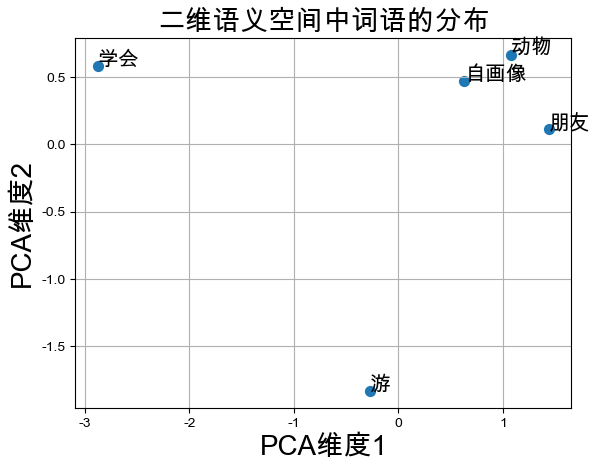

In [17]:
# 可视化

words = ['学会', '朋友', '动物', '游','自画像']
vectors = [model.wv[word] for word in words]

from sklearn.decomposition import PCA     # 语义空间降维，用于展示词语在二维空间的相对位置

# 使用PCA进行降维
pca = PCA(n_components = 2)
pca_result = pca.fit_transform(vectors)

import matplotlib.pyplot as plt     # 画图

# 绘制四个词语在二维空间的相对位置
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
plt.figure()

# 取PCA降维结果中所有行的第一列和第二列数据绘制散点图，设置点的大小为50
plt.scatter(pca_result[:, 0], pca_result[:, 1], s = 50)

for i, word in enumerate(words):
    plt.annotate(word, (pca_result[i, 0], pca_result[i, 1]), fontsize = 15)

plt.xlabel('PCA维度1', fontsize = 20)
plt.ylabel('PCA维度2', fontsize = 20)
plt.title('二维语义空间中词语的分布', fontsize = 20)
plt.grid(True)
plt.show()

In [18]:
import gensim
from gensim import corpora
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import warnings
warnings.filterwarnings('ignore')  # To ignore all warnings that arise here to enhance clarity

from gensim.models.coherencemodel import CoherenceModel
from gensim.models.ldamodel import LdaModel

In [19]:
from gensim.models import Word2Vec
txt=df['作文标题分词'].apply(lambda X: X.split()).tolist()#切分词语

In [20]:
dictionary = corpora.Dictionary(txt)  # 构建词典
corpus = [dictionary.doc2bow(text) for text in txt]  #表示为第几个单词出现了几次

In [21]:
ldamodel = LdaModel(corpus, num_topics=10, id2word = dictionary, passes=30,random_state = 1)   #分为10个主题
num_topics=10
print(ldamodel.print_topics(num_topics=num_topics, num_words=15)[:20])  #每个主题输出15个单词

[(0, '0.330*"学会" + 0.050*"小狗" + 0.035*"荷包蛋" + 0.033*"煮" + 0.026*"鸡蛋" + 0.024*"做饭" + 0.023*"炒鸡蛋" + 0.021*"煎" + 0.019*"骑车" + 0.019*"羽毛球" + 0.016*"西红柿" + 0.015*"弹钢琴" + 0.012*"湖" + 0.010*"天呐" + 0.009*"打篮球"'), (1, '0.165*"小猫" + 0.064*"乌龟" + 0.054*"时光" + 0.043*"幸福" + 0.037*"妈妈" + 0.025*"十八" + 0.024*"学骑" + 0.023*"记忆" + 0.022*"鹦鹉" + 0.021*"金鱼" + 0.015*"机" + 0.015*"场景" + 0.014*"花园" + 0.012*"一个" + 0.012*"兔"'), (2, '0.236*"乐园" + 0.108*"多功能" + 0.105*"书包" + 0.089*"飞屋" + 0.082*"梦想" + 0.080*"房子" + 0.021*"笔" + 0.021*"会飞" + 0.019*"万能" + 0.016*"房屋" + 0.014*"超级" + 0.007*"小白" + 0.007*"变小" + 0.006*"眼镜" + 0.006*"木屋"'), (3, '0.184*"自行车" + 0.176*"学会" + 0.172*"骑" + 0.106*"快乐" + 0.090*"天地" + 0.043*"我家" + 0.025*"仓鼠" + 0.014*"猫" + 0.013*"小天地" + 0.012*"魔法" + 0.012*"人物" + 0.007*"阳台" + 0.006*"笨笨" + 0.005*"百变" + 0.005*"瞬间"'), (4, '0.199*"学会" + 0.174*"奇思妙想" + 0.077*"游泳" + 0.052*"包" + 0.044*"饺子" + 0.042*"神奇" + 0.032*"新编" + 0.029*"赛跑" + 0.027*"龟兔" + 0.010*"画画" + 0.009*"滑板" + 0.009*"番茄" + 0.009*"蛋炒饭" + 0.007*"爱" + 0.007*

In [22]:
#计算困惑度
def perplexity(num_topics):
    ldamodel = LdaModel(corpus, num_topics=num_topics, id2word = dictionary, passes=30)
    print(ldamodel.print_topics(num_topics=num_topics, num_words=15))
    print(ldamodel.log_perplexity(corpus))
    return ldamodel.log_perplexity(corpus)

In [25]:
#计算coherence
def coherence(num_topics):
    ldamodel = LdaModel(corpus, num_topics=num_topics, id2word = dictionary, passes=30,random_state = 1)
    print(ldamodel.print_topics(num_topics=num_topics, num_words=10))
    ldacm = CoherenceModel(model=ldamodel, texts=txt, dictionary=dictionary, coherence='c_v')
    print(ldacm.get_coherence())
    return ldacm.get_coherence()

[(0, '0.071*"学会" + 0.061*"朋友" + 0.059*"动物" + 0.052*"游" + 0.035*"自画像" + 0.030*"智能" + 0.028*"自行车" + 0.026*"骑" + 0.022*"乐园" + 0.019*"汽车"')]
0.7114187419565778
[(0, '0.126*"学会" + 0.092*"游" + 0.053*"智能" + 0.050*"自行车" + 0.047*"骑" + 0.034*"汽车" + 0.029*"快乐" + 0.026*"奇思妙想" + 0.024*"天地" + 0.021*"公园"'), (1, '0.140*"朋友" + 0.134*"动物" + 0.081*"自画像" + 0.051*"乐园" + 0.023*"多功能" + 0.019*"小猫" + 0.017*"房子" + 0.015*"我家" + 0.012*"可爱" + 0.012*"会飞"')]
0.6904878854583558
[(0, '0.184*"学会" + 0.077*"智能" + 0.073*"自行车" + 0.068*"骑" + 0.049*"汽车" + 0.042*"快乐" + 0.037*"奇思妙想" + 0.036*"天地" + 0.018*"衣服" + 0.017*"游泳"'), (1, '0.205*"朋友" + 0.197*"动物" + 0.118*"自画像" + 0.027*"小猫" + 0.022*"我家" + 0.011*"乌龟" + 0.008*"科技" + 0.007*"猫" + 0.006*"魔法" + 0.006*"妈妈"'), (2, '0.165*"游" + 0.071*"乐园" + 0.037*"公园" + 0.033*"多功能" + 0.032*"书包" + 0.027*"飞屋" + 0.025*"梦想" + 0.024*"房子" + 0.024*"玉渊潭公园" + 0.016*"会飞"')]
0.6734629728210234
[(0, '0.217*"学会" + 0.086*"自行车" + 0.080*"骑" + 0.072*"智能" + 0.058*"汽车" + 0.044*"奇思妙想" + 0.021*"衣服" + 0.019*"游泳" + 0.01

0.6633920878571584
[(0, '0.350*"学会" + 0.187*"自行车" + 0.175*"骑" + 0.027*"小狗" + 0.019*"荷包蛋" + 0.018*"煮" + 0.014*"鸡蛋" + 0.013*"炒鸡蛋" + 0.012*"煎" + 0.010*"骑车"'), (1, '0.258*"小猫" + 0.052*"植物园" + 0.039*"十八" + 0.036*"记忆" + 0.032*"金鱼" + 0.024*"机" + 0.023*"场景" + 0.021*"咪咪" + 0.018*"人民" + 0.017*"爷爷"'), (2, '0.481*"乐园" + 0.068*"会飞" + 0.042*"笔" + 0.039*"万能" + 0.033*"房屋" + 0.023*"车" + 0.013*"眼镜" + 0.012*"木屋" + 0.010*"乡村" + 0.009*"房间"'), (3, '0.194*"书包" + 0.128*"我家" + 0.074*"仓鼠" + 0.038*"小天地" + 0.023*"学骑" + 0.022*"鹦鹉" + 0.021*"阳台" + 0.019*"笨笨" + 0.016*"画画" + 0.016*"瞬间"'), (4, '0.208*"学会" + 0.200*"奇思妙想" + 0.088*"游泳" + 0.060*"包" + 0.050*"饺子" + 0.044*"乌龟" + 0.037*"时光" + 0.028*"做饭" + 0.025*"妈妈" + 0.024*"未来"'), (5, '0.338*"智能" + 0.214*"汽车" + 0.055*"神奇" + 0.030*"新编" + 0.028*"飞行" + 0.027*"赛跑" + 0.026*"龟兔" + 0.024*"猫" + 0.021*"会飞" + 0.020*"超级"'), (6, '0.421*"游" + 0.095*"公园" + 0.061*"玉渊潭公园" + 0.047*"发明" + 0.022*"西湖" + 0.014*"故宫" + 0.013*"北京" + 0.009*"动物园" + 0.007*"杭州" + 0.006*"黄山"'), (7, '0.194*"飞屋" + 0.177*"梦

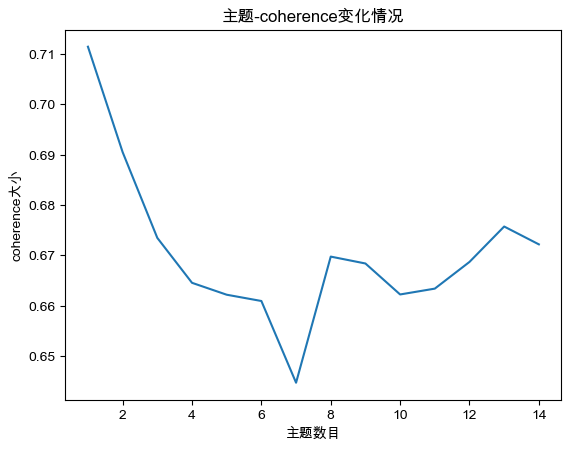

In [24]:
# 绘制困惑度折线图
x = range(1,15)
# z = [perplexity(i) for i in x]
y = [coherence(i) for i in x]
plt.plot(x, y)
plt.xlabel('主题数目')
plt.ylabel('coherence大小')
plt.rcParams['font.sans-serif']=['Arial Unicode MS']
matplotlib.rcParams['axes.unicode_minus']=False
plt.title('主题-coherence变化情况')
plt.show()

In [26]:
lda = LdaModel(corpus=corpus, id2word=dictionary, num_topics=5, passes = 30,random_state=1)
topic_list=lda.print_topics()
print(topic_list[:20])

[(0, '0.210*"学会" + 0.113*"自行车" + 0.105*"骑" + 0.060*"游" + 0.047*"公园" + 0.023*"发明" + 0.017*"小狗" + 0.013*"乌龟" + 0.012*"荷包蛋" + 0.011*"煮"'), (1, '0.307*"朋友" + 0.295*"动物" + 0.177*"自画像" + 0.013*"科技" + 0.008*"精彩" + 0.006*"记忆" + 0.006*"述说" + 0.006*"宠物" + 0.005*"金鱼" + 0.004*"场景"'), (2, '0.196*"游" + 0.119*"乐园" + 0.054*"多功能" + 0.045*"飞屋" + 0.041*"梦想" + 0.040*"房子" + 0.040*"玉渊潭公园" + 0.027*"会飞" + 0.014*"西湖" + 0.010*"笔"'), (3, '0.095*"快乐" + 0.081*"天地" + 0.058*"书包" + 0.048*"小猫" + 0.039*"我家" + 0.037*"智能" + 0.022*"仓鼠" + 0.012*"飞车" + 0.012*"猫" + 0.011*"小天地"'), (4, '0.124*"智能" + 0.100*"汽车" + 0.098*"学会" + 0.076*"奇思妙想" + 0.036*"衣服" + 0.034*"游泳" + 0.028*"可爱" + 0.025*"神奇" + 0.023*"包" + 0.019*"饺子"')]


In [27]:
result_list =[]
for i in lda.get_document_topics(corpus)[:]:
    listj=[]
    for j in i:
        listj.append(j[1])
    bz=listj.index(max(listj))
    result_list.append(i[bz][0])
print(result_list[:20])

[0, 4, 0, 2, 1, 2, 1, 3, 3, 4, 1, 2, 3, 1, 4, 2, 1, 2, 1, 3]


In [28]:
import pyLDAvis.gensim
pyLDAvis.enable_notebook()
data = pyLDAvis.gensim.prepare(lda, corpus, dictionary)
pyLDAvis.save_html(data, '四年级作文标题.html')